# **Perceptrons**

Neccessary libraries are imported here and some variables are predefined.

In [1]:
import numpy as np
from numpy.random import randn
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# make the code reproducible
np.random.seed(23)
w=0
b=0

## Dataset

A predefined 2D dataset

In [2]:
# Define the dataset
X_train = np.array([[1.5, 0.7], [1.6, 1.0], [2.0, 0.8], [1.2, 1.5], [0.7, 1.6], [1.7, 1.0], [0.8, 1.9], [0.9, 0.8], [1.1, 1.3], [1.0, 1.5], [1.5, 3.5], [2.5, 2.0], [3.0, 1.6], [3.0, 2.5], [2.0, 3.0], [2.8, 1.4], [3.2, 3.4], [2.5, 2.5], [3.5, 2.2], [2.5, 3.2]])
y_train = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

## Visualize Data

Write a function that plots the predefined data using X_train and y_train in a 2D space. make the points that are tagged +1 red circles and the other points blue squares.

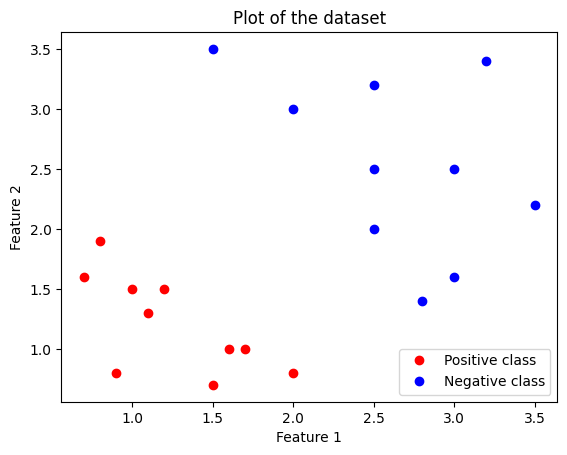

In [3]:
def plot_data(X,y):
  
  plt.plot(X[y==1,0], X[y==1,1], 'ro', label='Positive class')
  plt.plot(X[y==-1,0], X[y==-1,1], 'bo', label='Negative class')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.title('Plot of the dataset')
  plt.legend()
  plt.show()
  # write your answer here
  
  return

plot_data(X_train,y_train)

## Example classifier line

First, define a function that takes
examples in the form of {(X,*y*)}, as well as parameters *w* and *b*. Then, plot the examples as scatter points and overlay the line given by *w.x+b*=0.
Then, through trial and error, find values for *w* and *b* such that the line *w.x+b*=0 separates all the points correctly.

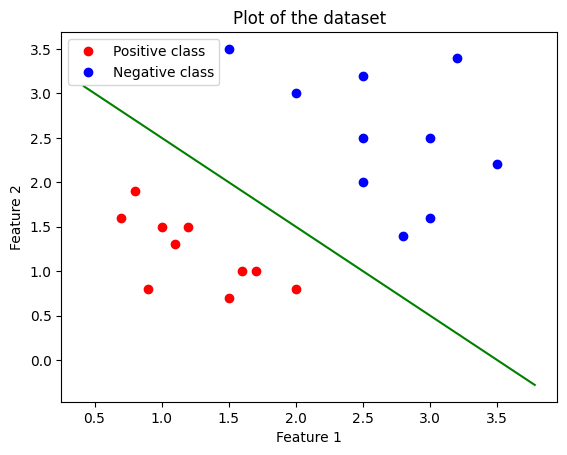

In [11]:
def plot_perceptron(X,y,w,b):
  plt.plot(X[y==1,0], X[y==1,1], 'ro', label='Positive class')
  plt.plot(X[y==-1,0], X[y==-1,1], 'bo', label='Negative class')
  plt.xlabel('Feature 1')
  plt.ylabel('Feature 2')
  plt.title('Plot of the dataset')
  plt.legend()
  
  max_x = max(X[:,0])
  min_x = min(X[:,0])
  x_max_lim = max_x + 0.1 * (max_x - min_x)
  x_min_lim = min_x - 0.1 * (max_x - min_x)
  x = np.linspace(x_min_lim,x_max_lim,100)
  y = -1/w[1]*(w[0]*x + b)
  plt.plot(x, y, '-g', label='y=wx+b')
  plt.show()

# Find w and b through trial and error:

# w=?
# b=?
w, b = [1, 1], -3.5
plot_perceptron(X_train,y_train,w,b)

## Train a simple binary classifier perceptron

Implement the perceptron algorithm in a function that was mentioned in the slides 1.

Inputs to Perceptron are:
* X = data points
* Y = tags
* w_initial = initial guess of w
* b_initial = initial guess of b

optional inputs **(5 more bonus points for each argument implementation)**:
* maxchecks = maximum number of data points to look out, which may or may not violate the perceptron condition
* maxiters = maximum number of updates to w
* learning_rate

Perceptron should start with the input guess of w, look at most maxchecks data points and make at most maxiters updates, and return the final w and b.

Use plot_perceptron to plot you result with the new w and b.

reference: slide 33 from فصل اول: از نورون بیولوژیکی تا پرسپترون
   


Learning rate:  1
Total updates:  46
Final update at iteration: 261
Optimal weights: [ -4. -10.]
Optimal bias: 23.0
--------------------
Learning rate:  0.1
Total updates:  46
Final update at iteration: 261
Optimal weights: [-0.4 -1. ]
Optimal bias: 2.3
--------------------
Learning rate:  0.01
Total updates:  46
Final update at iteration: 261
Optimal weights: [-0.04 -0.1 ]
Optimal bias: 0.22999999999999995
--------------------
Learning rate:  0.001
Total updates:  46
Final update at iteration: 261
Optimal weights: [-0.004 -0.01 ]
Optimal bias: 0.023000000000000007
--------------------


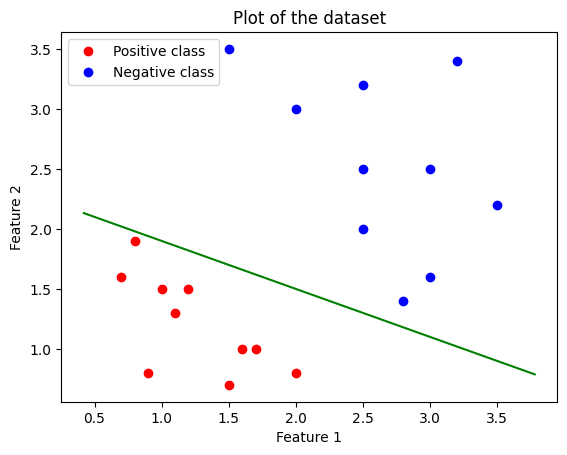

In [12]:
def train_perceptron(X, y, w_initial, b_initial, learning_rate=0.1, max_checks=500, maxiters=100):
    w, b = np.array(w_initial), b_initial
    update_counter = 0
    
    def predict(X, w, b):
        return np.sign(np.dot(X, w) + b)
    
    def update_weights(x, y, yk, w, b, learning_rate):
        w = w + (y - yk) * learning_rate * x
        b = b + (y - yk) * learning_rate
        return w, b
        
    counter = 0
    final_update_counter = -1
    while counter < max_checks:
        counter += 1
        i = counter % len(X) # if we have passed through all the data, start again
        yk = predict(X[i], w, b)
        if not np.array_equal(yk, y[i]) and update_counter < maxiters:
            update_counter += 1
            final_update_counter = counter
            w, b = update_weights(X[i], y[i], yk, w, b, learning_rate)

    print("Learning rate: ", learning_rate)
    print("Total updates: ", update_counter)
    print("Final update at iteration:", final_update_counter)
    return w, b

X = X_train
y = y_train

w_initial = np.array([0, 0])
b_initial = 0

for learning_rate in [1, 0.1, 0.01, 0.001]:
    w, b = train_perceptron(X, y, w_initial, b_initial, learning_rate=learning_rate)
    print("Optimal weights:", w)
    print("Optimal bias:", b)
    print("--------------------")

plot_perceptron(X,y,w,b)

## Another dataset

Try to write a function that creates two clusters of data using num_samples, their centroids and a standard deviation and run the train_perceptron function that you wrote on it. try to classify the points and plot the results like before.

Learning rate:  0.1
Total updates:  26644
Final update at iteration: 150000
Optimal weights: [ 1.85058585 -1.96750827]
Optimal bias: 0.7


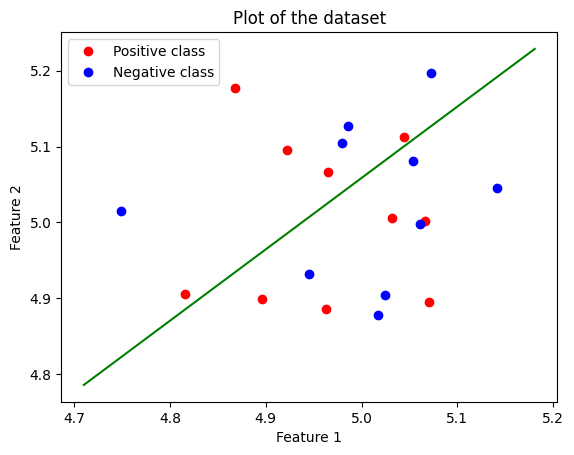

In [17]:
def create_blob(num_samples = 100, centroid1=[2, 2], centroid2=[6, 6], std=0.8):

  # write your answer here
  np.random.seed(23)
  points1 = np.random.normal(loc=centroid1, scale=std, size=(num_samples // 2, len(centroid1)))
  points2 = np.random.normal(loc=centroid2, scale=std, size=(num_samples // 2, len(centroid2)))
  X = np.concatenate([points1, points2])
  y = np.concatenate([np.ones(num_samples // 2), -1 * np.ones(num_samples // 2)])
  
  return X,y

X, y = create_blob(20, [5, 5], [5, 5], 0.1)

w_initial = np.array([0, 0])
b_initial = 0
learning_rate = 0.1

w, b = train_perceptron(X, y, w_initial, b_initial, learning_rate, maxiters=1500000, max_checks=150000)
print("Optimal weights:", w)
print("Optimal bias:", b)

plot_perceptron(X,y,w,b)

PART 2 : AutoEncoders

In [18]:

import torch
import torch.utils as utils
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as td
import torchvision.transforms as transforms
import torchvision.utils as vutils

transform = transforms.Compose([
    transforms.ToTensor()
])

mnist_train = td.MNIST(root='./data/train', train=True, download=True, transform=transform)
mnist_train_loader = utils.data.DataLoader(dataset=mnist_train, batch_size=64, shuffle=True)

mnist_test = td.MNIST(root='./data/test', train=False, download=True, transform=transform)
mnist_test_loader = utils.data.DataLoader(dataset=mnist_test, batch_size=64, shuffle=False)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Hyper parameters
num_epochs = 5
num_classes = 10
batch_size = 100
learning_rate = 0.001


In [19]:
import matplotlib.pyplot as plt
import numpy as np

class Autoencoder(nn.Module):
    def __init__(self, criterion = nn.MSELoss(), save_path = 'autoencoder.pth', learning_rate = 0.01):
        super(Autoencoder, self).__init__()
        self.criterion = criterion
        self.save_path = save_path
        self.learning_rate = learning_rate
        
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )
        
    def decode(self, x):
        return self.decoder(x)
    
    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the image
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        decoded = decoded.view(-1, 1, 28, 28)  # Reshape back to image size
        return decoded
    
    def my_train(self, optimizer = None, num_epochs = 5, train_data = mnist_train_loader):
        optimizer = optim.Adam(self.parameters(), lr=self.learning_rate) if optimizer is None else optimizer
        
        loss_list = []
        for epoch in range(num_epochs):
            for data in train_data:
                img, _ = data
                img = img.to(device)
                
                # Forward pass
                output = self(img)
                loss = self.criterion(output, img)
                
                # Backward pass and optimization
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            loss_list.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
            
        torch.save(self.state_dict(), self.save_path)
        
        plt.plot(loss_list)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.show()
        
    def my_test_loss(self, test_data = mnist_test_loader):
        self.load_state_dict(torch.load(self.save_path))
        self.eval()
        test_loss = 0.0
        
        with torch.no_grad():
            for data in test_data:
                img, _ = data
                img = img.to(device)
                
                # Forward pass to get the reconstructed images
                output = self(img)
                
                # Compute the loss
                loss = self.criterion(output, img)
                test_loss += loss.item()

        # Average test loss
        test_loss /= len(test_data)
        print(f'Average test loss: {test_loss:.4f}')
        
    def my_test(self, x):
        self.load_state_dict(torch.load(self.save_path))
        self.eval()
        
        with torch.no_grad():
            x = x.to(device)
            output = self(x)
            return output
        
# Visualize some of the original and reconstructed images
    def visualize(self, test_data = mnist_test_loader):
        def imshow(img, title):
            # img = img / 2 + 0.5  # Unnormalize
            npimg = img.numpy()
            plt.imshow(np.transpose(npimg, (1, 2, 0)))
            plt.title(title)
            plt.show()
            
        
        # Get a batch of test images
        dataiter = iter(test_data)
        images, labels = next(dataiter)

        # Get reconstructed images
        images = images.to(device)
        output = self(images)

        # Move images to CPU for visualization
        images = images.cpu()
        output = output.cpu()

        # Show original images
        imshow(vutils.make_grid(images), 'Original Images')

        # Show reconstructed images
        imshow(vutils.make_grid(output), 'Reconstructed Images')

Epoch [1/5], Loss: 0.0382
Epoch [2/5], Loss: 0.0280
Epoch [3/5], Loss: 0.0225
Epoch [4/5], Loss: 0.0262
Epoch [5/5], Loss: 0.0194


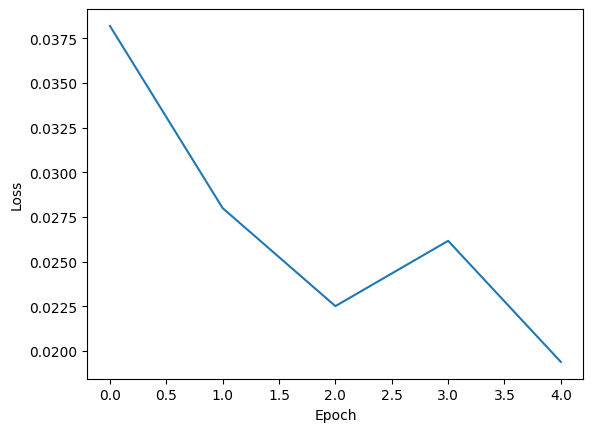

In [20]:
model = Autoencoder(learning_rate=0.001).to(device)
model.my_train()

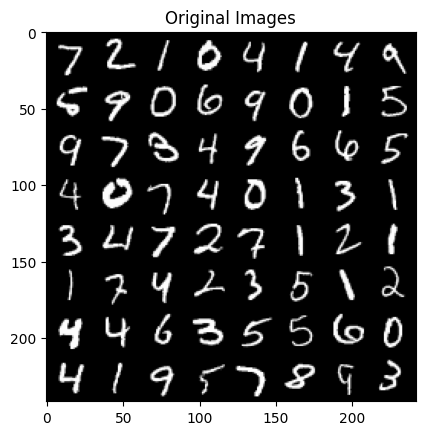

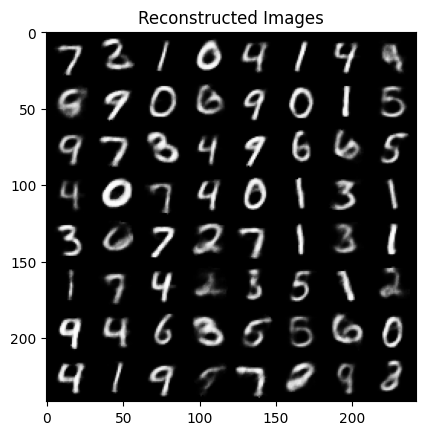

In [21]:
model.visualize()

In [22]:
model.my_test_loss()

Average test loss: 0.0221


In [23]:
from sklearn.manifold import Isomap

def isomap_projection(data, title, n_components=2, n_neighbors=5):
    isomap = Isomap(n_components=n_components, n_neighbors=n_neighbors)
    isomap.fit(data.cpu().detach().numpy())

    X_isomap = isomap.transform(data.cpu().detach().numpy())
    y_isomap = mnist_test.targets.cpu().detach().numpy()

    plt.figure(figsize=(10, 10))
    for i in range(10):
        plt.scatter(X_isomap[y_isomap == i, 0], X_isomap[y_isomap == i, 1], label=str(i))
    plt.legend()
    plt.title(title)

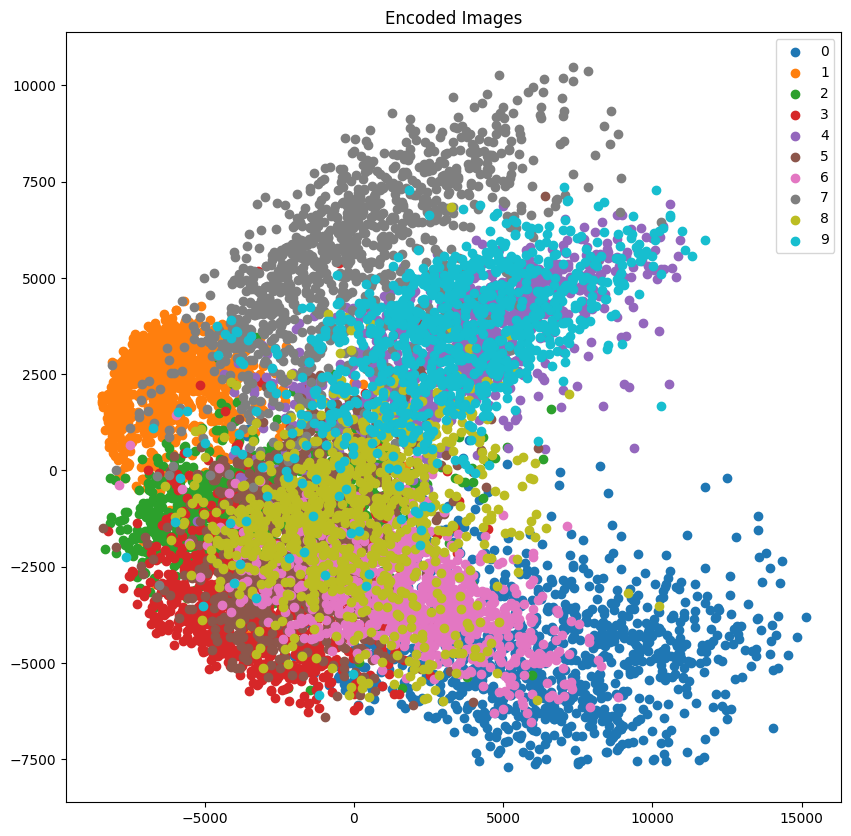

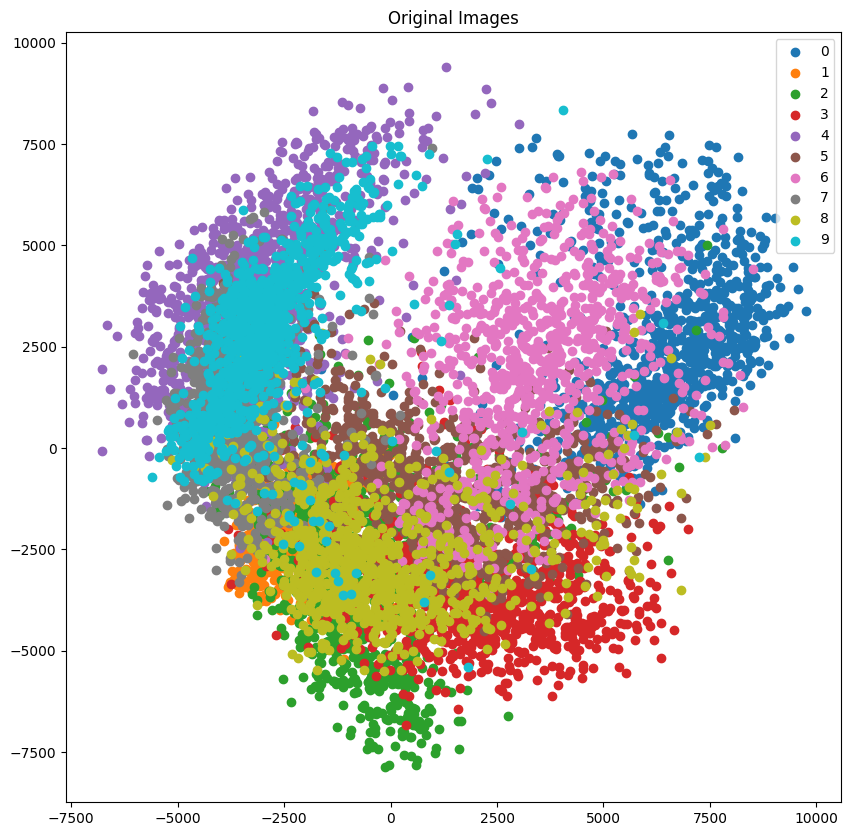

In [24]:
encoded_images = model.encode(mnist_test.data.to(device).view(-1, 28 * 28).float())
original_images = mnist_test.data.to(device).view(-1, 28 * 28).float()

isomap_projection(encoded_images, 'Encoded Images')
isomap_projection(original_images, 'Original Images')

Part 6

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

class SimpleNN(nn.Module):
    def __init__(self, 
                 criterion = nn.CrossEntropyLoss(),
                 input_size = 16,
                 hidden_size = 32,
                 num_classes = 10,
                 num_epochs = 20):
        
        super(SimpleNN, self).__init__()
        self.criterion = criterion
        self.num_epochs = num_epochs
        
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.softmax(out)
        return out
    
    def my_train(self, train_loader: torch.utils.data.TensorDataset, optimizer = None, num_epochs = 5):
        optimizer = optim.Adam(self.parameters(), lr=0.001) if optimizer is None else optimizer
        
        loss_list = []
        
        for epoch in range(self.num_epochs):
            for data in train_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                
                # Forward pass
                outputs = self(inputs)
                loss = self.criterion(outputs, labels)
                
                # Backward and optimize
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            loss_list.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')
            
        plt.plot(loss_list)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.show()
            
            
    def my_test(self, test_loader: torch.utils.data.TensorDataset):
        # confusion matrix and classification report
        
        self.eval()
        y_true = []
        y_pred = []
        
        with torch.no_grad():
            for data in test_loader:
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)
                
                # Forward pass
                outputs = self(inputs)
                _, predicted = torch.max(outputs.data, 1)
                
                y_true.extend(labels.cpu().numpy())
                y_pred.extend(predicted.cpu().numpy())
                
        cm = confusion_matrix(y_true, y_pred)
        cr = classification_report(y_true, y_pred)
        
        print('Confusion Matrix')
        plt.figure(figsize=(10, 7))
        sns.heatmap(cm, annot=True, fmt='g')
        plt.show()
        
        print('Classification Report')
        print(cr)
        
            
    def evaluate_model(self, test_loader: torch.utils.data.TensorDataset):
        self.my_test(test_loader)
        

In [34]:
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]

In [35]:
def encode_mnist_data(data, autoencoder):
    
    encoded_train_data = []
    encoded_train_labels = []
    encoded_test_data = []
    encoded_test_labels = []

    autoencoder.eval()
    with torch.no_grad():
        for data in mnist_train_loader:
            img, label = data
            img = img.to(device)
            # mnist_test.data.to(device).view(-1, 28 * 28).float()
            encoded = autoencoder.encode(img.view(-1, 28 * 28).float())
            encoded_train_data.append(encoded.cpu())
            encoded_train_labels.append(label)
        
        for data in mnist_test_loader:
            img, label = data
            img = img.to(device)
            encoded = autoencoder.encode(img.view(-1, 28 * 28).float())
            encoded_test_data.append(encoded.cpu())
            encoded_test_labels.append(label)

    
    encoded_train_data = torch.cat(encoded_train_data)
    encoded_train_labels = torch.cat(encoded_train_labels)
    encoded_test_data = torch.cat(encoded_test_data)
    encoded_test_labels = torch.cat(encoded_test_labels)

    return {
        'train_d': encoded_train_data,
        'train_l': encoded_train_labels,
        'test_d': encoded_test_data,
        'test_l': encoded_test_labels
    }

Epoch [1/5], Loss: 1.7481
Epoch [2/5], Loss: 1.5465
Epoch [3/5], Loss: 1.6181
Epoch [4/5], Loss: 1.5767
Epoch [5/5], Loss: 1.5763
Epoch [6/5], Loss: 1.6042
Epoch [7/5], Loss: 1.6135
Epoch [8/5], Loss: 1.6745
Epoch [9/5], Loss: 1.6690
Epoch [10/5], Loss: 1.6417
Epoch [11/5], Loss: 1.6056
Epoch [12/5], Loss: 1.5986
Epoch [13/5], Loss: 1.6150
Epoch [14/5], Loss: 1.6225
Epoch [15/5], Loss: 1.5240
Epoch [16/5], Loss: 1.5709
Epoch [17/5], Loss: 1.6509
Epoch [18/5], Loss: 1.5643
Epoch [19/5], Loss: 1.5574
Epoch [20/5], Loss: 1.6767


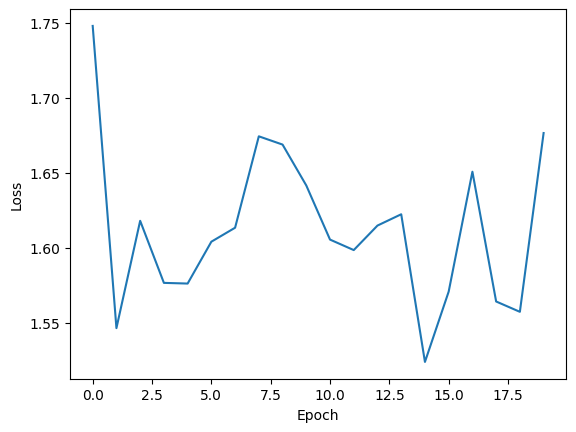

c:\Users\Hossein\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hossein\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Hossein\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(av

Confusion Matrix


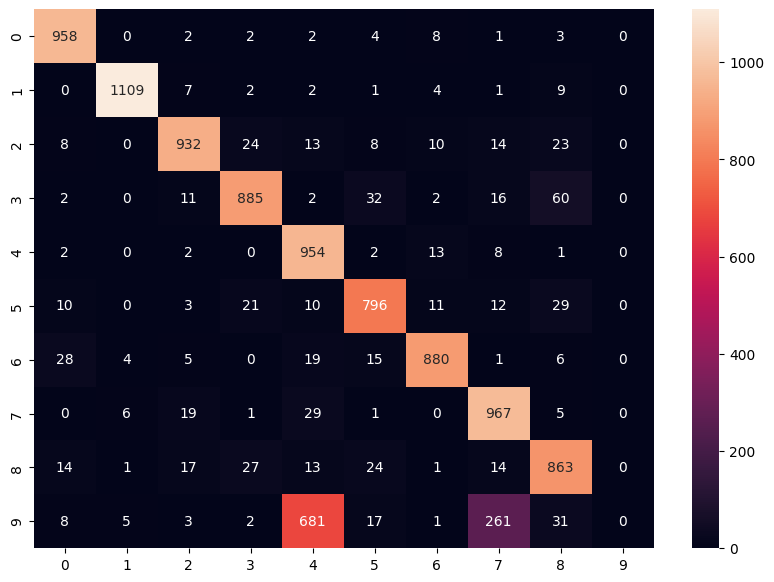

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.98      0.95       980
           1       0.99      0.98      0.98      1135
           2       0.93      0.90      0.92      1032
           3       0.92      0.88      0.90      1010
           4       0.55      0.97      0.70       982
           5       0.88      0.89      0.89       892
           6       0.95      0.92      0.93       958
           7       0.75      0.94      0.83      1028
           8       0.84      0.89      0.86       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.83     10000
   macro avg       0.77      0.83      0.80     10000
weighted avg       0.77      0.83      0.80     10000



In [ ]:
encoded = encode_mnist_data(mnist_train_loader, model)

simple_model = SimpleNN(num_epochs = 20).to(device)

train_dataset = CustomDataset(encoded['train_d'], encoded['train_l'])
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)

test_dataset = CustomDataset(encoded['test_d'], encoded['test_l'])
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

simple_model.my_train(train_loader)

simple_model.my_test(test_loader)
